# Dev32: Apply 028 SVM Model to 057 Transect

**Goal**: Use the trained SVM from dev30 (trained on 028) and apply it to 057 transect.

**Workflow**:
1. Load saved SVM model from dev30
2. Load and preprocess 057 transect (same preprocessing as dev30)
3. Classify entire segment
4. Apply filtering (remove small clusters)
5. Visualize with plot_georef (like dev20)

## Setup and Import

In [1]:
import importlib
import sys
from pathlib import Path
import pickle


# Add mjosa_code root to path
mjosa_code_root = Path.cwd().parent  # Up to mjosa_code root
sys.path.insert(0, str(mjosa_code_root))

# Import from mjosa_code (NEW structure)
from utils.uhi import georef
from utils.common import config

importlib.reload(georef)
from utils.uhi.georef import *

## Step 1: Load Trained SVM Model from dev30

**Note**: First run the save cell in dev30 to create the model file!

In [ ]:
# Load the saved SVM model and preprocessing info
model_file = "./saved_data/svm_model_028_multiclass.pkl"

if not os.path.exists(model_file):
    print("❌ ERROR: Model file not found!")
    print(f"   Looking for: {model_file}")
    print("\n📝 TO CREATE THE MODEL FILE:")
    print("   1. Open dev30 notebook")
    print("   2. Run all cells up to 'Train SVM'")
    print("   3. Run the '💾 SAVE SVM MODEL' cell")
    print("   4. Then come back here!")
    raise FileNotFoundError(f"Model file not found: {model_file}")
else:
    with open(model_file, "rb") as f:
        saved_model_data = pickle.load(f)

    # Extract model and parameters
    trained_model = saved_model_data["model"]
    class_names = saved_model_data["class_names"]
    label_encoder = saved_model_data["label_encoder"]
    preprocessing_params = saved_model_data["preprocessing"]
    best_params = saved_model_data["best_params"]

    print("✅ SVM model loaded successfully!")
    print(f"\n📊 Model Info:")
    print(f"   Classes: {class_names}")
    print(f"   Best C: {best_params['C']}")
    print(f"   Best gamma: {best_params['gamma']}")
    print(f"\n🔬 Preprocessing (will apply to 057):")
    print(
        f"   Smoothing: {preprocessing_params['smoothing_method']} (σ={preprocessing_params['smoothing_sigma']})"
    )
    print(f"   Wavelength range: {preprocessing_params['wavelength_range']} nm")
    print(f"   Normalization: {preprocessing_params['normalization']}")

✅ SVM model loaded successfully!

📊 Model Info:
   Classes: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']
   Best C: 10
   Best gamma: 0.1

🔬 Preprocessing (will apply to 057):
   Smoothing: gaussian (σ=5.0)
   Wavelength range: (490, 700) nm
   Normalization: None


## Step 2: Load 057 Transect (File 5)

In [3]:
# Load transect
transect = load_transect(config.TRANSECT_057_OUTPUT)
transect.list_files()

# Select file
cube = transect.select_files(["rad_uhi_20241029_115057_5"])
cube.describe()


📋 Files in output (corrected=False):
 1. rad_uhi_20241029_115057_1  | shape=(1333, 968, 210)  | has_georef=True
 2. rad_uhi_20241029_115057_2  | shape=(1946, 968, 210)  | has_georef=True
 3. rad_uhi_20241029_115057_3  | shape=(2227, 968, 210)  | has_georef=True
 4. rad_uhi_20241029_115057_4  | shape=(2463, 968, 210)  | has_georef=True
 5. rad_uhi_20241029_115057_5  | shape=(2462, 968, 210)  | has_georef=True
 6. rad_uhi_20241029_115057_6  | shape=(155, 968, 210)  | has_georef=True
🔄 Rebuilding grids from georef hits for selected files...
   • rad_uhi_20241029_115057_5
  rad_uhi_20241029_115057_5: Using GRIDDED format (T=2462, S=968)
✅ Combined shapes: X/Y/Z (2462, 968), RGB (2462, 968)
🔄 Loading full hyperspectral cube...
   • Loading rad_uhi_20241029_115057_5...
✅ Loaded full cube: (2462, 968, 210) (T × S × B)

=== Combined_output ===
Tracks × Slits: 2462 × 968
Spectral bands: 210
RGB coverage: R/G/B finite ratios 1.00/1.00/1.00

📊 Spectral configuration:
   Wavelength range: 380.9 -

In [4]:
# Apply illumination correction
cube.apply_illumination_correction_v2()
print("✅ Illumination correction applied")

🔄 Using V2 algorithm (pandas rolling median, memory-efficient)
✅ Illumination correction already applied with window=500, strength=1.0
   Loading from disk...
📂 Loading saved illumination correction from 1 files...
   rad_uhi_20241029_115057_5: window=500, strength=1.0
✅ Loaded illumination correction from disk
✅ Illumination correction applied


## Step 3: Apply Same Preprocessing as dev30

In [5]:
# Apply spectral smoothing (same as dev30)
cube.apply_spectral_smoothing(
    method=preprocessing_params["smoothing_method"],
    gaussian_sigma=preprocessing_params["smoothing_sigma"],
)
print(
    f"✅ Spectral smoothing applied: {preprocessing_params['smoothing_method']} (σ={preprocessing_params['smoothing_sigma']})"
)

💾 Found cached smoothing (gaussian, corrected data) - loading from disk (much faster!)
📂 Loading saved spectral smoothing (gaussian, corrected data) from 1 files...
   rad_uhi_20241029_115057_5: method=gaussian
✅ Loaded spectral smoothing from disk (saved computation time!)
✅ Spectral smoothing applied: gaussian (σ=5.0)


In [6]:
# Crop wavelengths (same as dev30)
wl_min, wl_max = preprocessing_params["wavelength_range"]
cube.apply_wavelength_filter(wavelength_range=(wl_min, wl_max))

print(f"✅ Wavelength cropping complete")
print(f"   Cropped shape: {cube.data_corrected.shape}")
print(f"   Wavelength range: {cube.wavelengths[0]:.1f} - {cube.wavelengths[-1]:.1f} nm")

🔪 WAVELENGTH FILTERING
📊 Original wavelengths: 210
🎯 Target range: 490-700 nm
✂️  Filtered wavelengths: 119
📉 Range: 490.2 - 699.4 nm

✅ Datacube shape after filtering: (2462, 968, 119)
   Memory: 1.06 GB
✅ Wavelength cropping complete
   Cropped shape: (2462, 968, 119)
   Wavelength range: 490.2 - 699.4 nm


In [7]:
# NO L2 normalization (like dev30)
print("✅ No normalization applied (matching dev30 preprocessing)")

✅ No normalization applied (matching dev30 preprocessing)


## Step 4: Classify Entire Segment (using dev30's model)

**Note**: We're using the trained model from 028, applying it to 057 data.

## Step 3.5: Set the Loaded Model on the Cube

The `classify_segment()` method uses the model stored in the cube object. We need to set it manually.

In [8]:
# Set the loaded model on the cube object
# (classify_segment() expects these attributes to exist)
cube.svm_model = trained_model
cube.svm_label_encoder = label_encoder
cube.svm_class_names = class_names

print("✅ Model set on cube object")
print(f"   cube.svm_model: {type(cube.svm_model)}")
print(f"   cube.svm_label_encoder: {type(cube.svm_label_encoder)}")
print(f"   cube.svm_class_names: {cube.svm_class_names}")

✅ Model set on cube object
   cube.svm_model: <class 'sklearn.svm._classes.SVC'>
   cube.svm_label_encoder: <class 'sklearn.preprocessing._label.LabelEncoder'>
   cube.svm_class_names: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']


In [9]:
# Get track range for file 5 (from config or manually)
track_start = config.UHI_TRACK_RANGE[0] if hasattr(config, "UHI_TRACK_RANGE") else 0
track_end = (
    config.UHI_TRACK_RANGE[1]
    if hasattr(config, "UHI_TRACK_RANGE")
    else cube.data_corrected.shape[0]
)

print(f"🔍 Track range for classification: [{track_start}, {track_end}]")
print(f"   Total tracks: {track_end - track_start}")

🔍 Track range for classification: [576, 1566]
   Total tracks: 990


In [10]:
# Classify using the loaded model from dev30
print("\n🎯 Classifying 057 transect using 028-trained model...")
print("=" * 60)

classification_results = cube.classify_segment(
    segment_start=track_start,
    segment_end=track_end - 1,
    use_corrected=True,
    confidence_threshold=0,  # Reject low-confidence pixels → classified_unknown
    quiet=False,
)

print(f"\n✅ Classification complete!")
print(f"   Classes: {classification_results['class_names']}")
print(f"\n📊 Pixel counts:")
for class_name in classification_results["class_names"]:
    count = np.sum(classification_results["classification_map"] == class_name)
    percentage = 100.0 * count / classification_results["classification_map"].size
    print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")


🎯 Classifying 057 transect using 028-trained model...
🎯 SEGMENT CLASSIFICATION (no filtering, no validation)
🎲 Confidence threshold: 0.00
   (Pixels with max_prob < 0.00 → classified_unknown)
🎯 SEGMENT CLASSIFICATION WITH VALIDATION

📦 Datacube shape: (2462, 968, 119)
📏 Using data: corrected
🎯 Segment range: tracks 576 to 1565

🔪 Extracting segment...
   Segment shape: (990, 968, 119)

🤖 Classifying 958320 pixels...


   Classifying: 100%|█████████████████████████████████| 958320/958320 [01:57<00:00, 8189.13pixels/s]



🎲 Confidence Thresholding:
   Threshold: 0.00
   Unknown pixels: 0 (0.0%)
   Confidence range: [0.315, 1.000]
   ✅ Classification complete in 117.57 seconds

📊 Classification distribution (before filtering):
   dark_bomb: 5383 pixels (0.6%)
   dark_pit: 125100 pixels (13.1%)
   halo: 43617 pixels (4.6%)
   rust: 53 pixels (0.0%)
   sediment: 784167 pixels (81.8%)

✅ Classification and validation complete!

✅ Classification complete!
   Classes: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']

📊 Pixel counts:
   sediment: 784167 pixels (81.8%)
   rust: 53 pixels (0.0%)
   dark_bomb: 5383 pixels (0.6%)
   dark_pit: 125100 pixels (13.1%)
   halo: 43617 pixels (4.6%)


## Step 5: Visualize Classification Results

Plot the raw classification (before filtering)

In [11]:
# Define class name mapping for display
class_display_names = {
    "dark_bomb": "dark area near bomb",
    "dark_pit": "isolated dark area",
    "halo": "halo",
    "rust": "rust",
    "sediment": "sediment",
}

# Define custom color map using hardcoded colors
roi_color_map = {
    "dark area near bomb": "#000000",  # COLOR_DARK - black
    "isolated dark area": "#3F3F3F",  # COLOR_DARK_SEDIMENT - medium-dark gray
    "halo": "#e5e57f",  # COLOR_HALO - yellow-ish
    "rust": "#b12222",  # COLOR_SEDIMENT - saddle brown
    "sediment": "#8b4513",  # COLOR_SEDIMENT - saddle brown
}

📊 Plotting classification map...
   ROIs created: ['sediment', 'rust', 'dark area near bomb', 'isolated dark area', 'halo']
   Pixel counts:
      dark area near bomb: 5383 pixels
      halo: 43617 pixels
      isolated dark area: 125100 pixels
      rust: 53 pixels
      sediment: 784167 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates


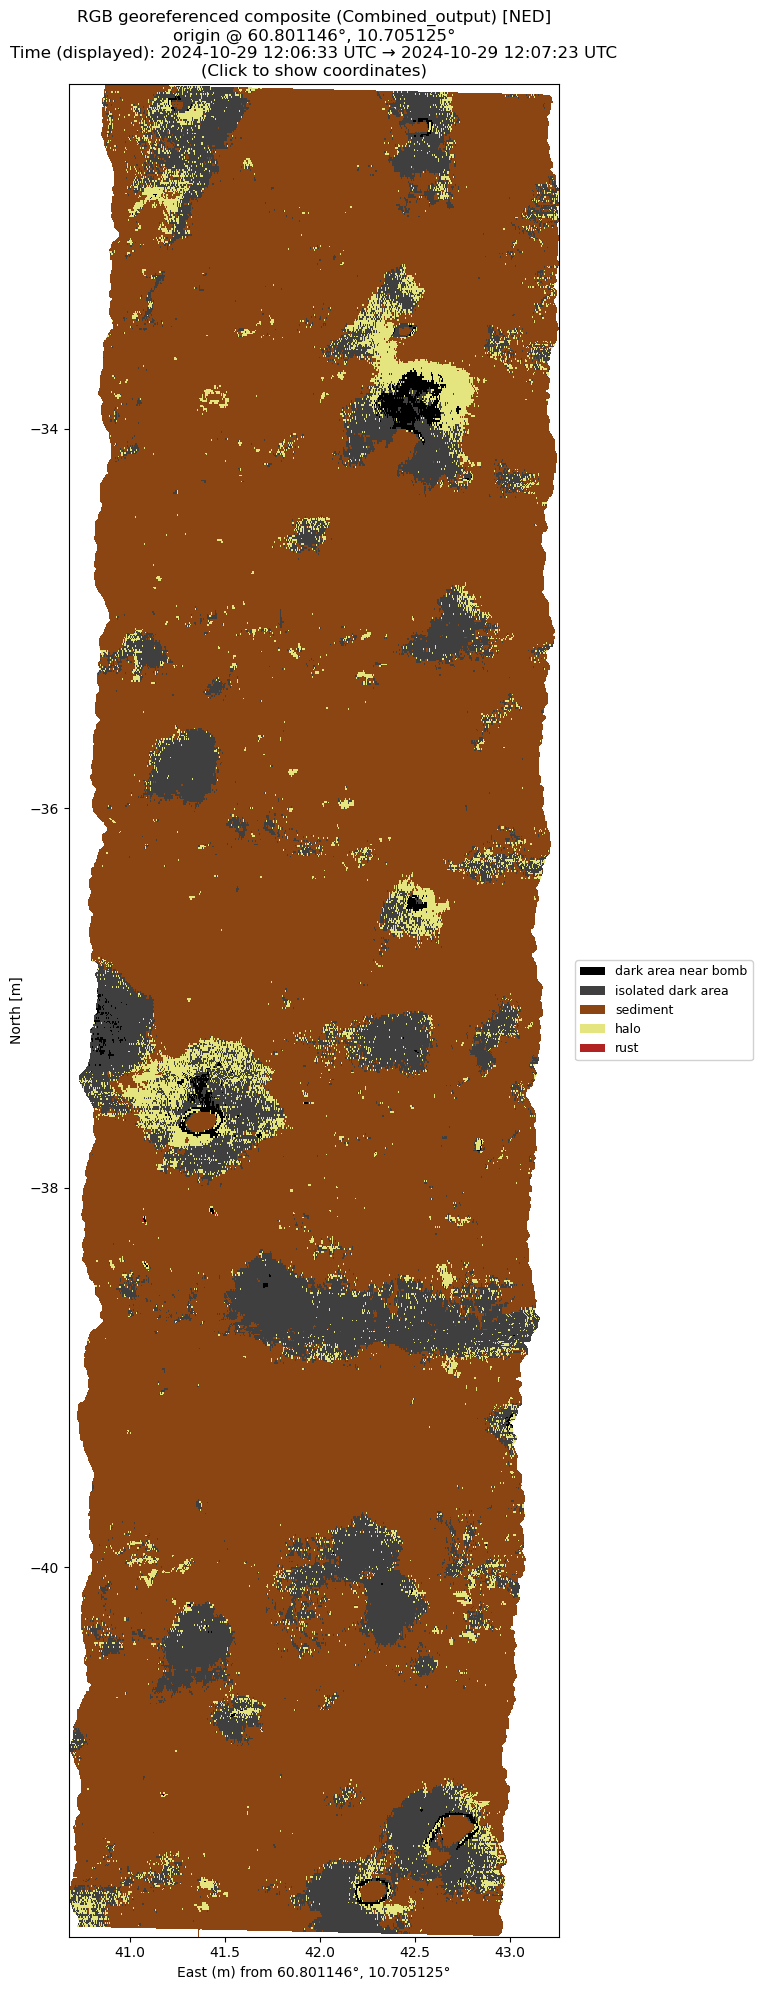

In [12]:
%matplotlib inline

# Convert classification map to ROI format for plotting
print("📊 Plotting classification map...")

# Map internal class names to display names requested by user
class_display_names = {
    "dark_bomb": "dark area near bomb",
    "dark_pit": "isolated dark area",
    # other classes will keep their original names
}

# Hardcoded color map for display names
roi_color_map = {
    "dark area near bomb": "#000000",   # COLOR_BOMBS
    "isolated dark area": "#3F3F3F",    # COLOR_DARK
    "sediment": "#8b4513",
    "rust": "#b12222",
    "halo": "#e5e57f",
}

classification_rois = {}
for class_name in classification_results['class_names']:
    mask = classification_results['classification_map'] == class_name
    rows, cols = np.where(mask)
    # Convert to global coordinates (add track_start offset)
    pixels = [(col, row + track_start) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        display_name = class_display_names.get(class_name, class_name)
        classification_rois[display_name] = pixels

print(f"   ROIs created: {list(classification_rois.keys())}")
print(f"   Pixel counts:")
for class_name in sorted(classification_rois.keys()):
    print(f"      {class_name}: {len(classification_rois[class_name])} pixels")

# Plot with plot_georef (like dev20) and pass the color map and overlay mode
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start,
    track_end=track_end,
    figsize=(50, 20),
    roi_collection=classification_rois,
    roi_overlay_mode="solid",
    roi_color_map=roi_color_map,

    roi_marker_size=1,
    roi_legend_loc="outside",
    roi_legend_markersize=50,
    roi_show_numbers=False,
    roi_legend_show_counts=False,  # Don't show pixel counts in legend labels
)

## Step 6: Apply Filtering (like dev20)

Remove small clusters of dark_bomb, dark_pit, and halo (similar to dev20's filtering)

In [ ]:
# Apply filtering to remove small clusters
print("\n🧹 FILTERING: Removing small clusters...")
print("=" * 60)

# Define which classes to filter (keep sediment and rust as is)
classes_to_filter = ["dark_bomb", "dark_pit", "halo"]

# Step 1: Filter dark_bomb and dark_pit using built-in function
filtering_results = cube.filter_classification(
    classification_map=classification_results["classification_map"],
    class_names=classification_results["class_names"],
    filter_bombs=True,  # Filter dark_bomb
    filter_dark=True,  # Filter dark_pit (has "dark" in name)
    min_area_px=10,  # Minimum cluster size (pixels)
    quiet=False,
)

# Step 2: Manually filter halo (since filter_classification doesn't have filter_halo parameter)
print(f"\n🧹 Manually filtering halo class...")
from scipy.ndimage import label

filtered_map = filtering_results["filtered_map"].copy()

if "halo" in filtering_results["all_classes"]:
    halo_mask = filtered_map == "halo"
    halo_count_before = np.sum(halo_mask)

    # Label connected components
    labeled_halo, n_components = label(halo_mask, structure=np.ones((3, 3)))

    # Remove small clusters
    filtered_halo_count = 0
    for component_id in range(1, n_components + 1):
        component_mask = labeled_halo == component_id
        component_size = np.sum(component_mask)

        if component_size < 10:  # Same min_area_px as other classes
            # Mark as filtered_halo
            filtered_map[component_mask] = "filtered_halo"
        else:
            filtered_halo_count += component_size

    halo_removed = halo_count_before - filtered_halo_count
    print(
        f"   halo: {halo_count_before} → {filtered_halo_count} pixels ({halo_removed} removed)"
    )

    # Update filtering_results
    filtering_results["filtered_map"] = filtered_map
    filtering_results["all_classes"] = sorted(np.unique(filtered_map))

print(f"\n✅ Filtering complete (including halo)!")
print(f"\n📊 Pixel counts after filtering:")
# Use 'all_classes' which contains all unique classes in filtered map
for class_name in filtering_results["all_classes"]:
    count = np.sum(filtering_results["filtered_map"] == class_name)
    percentage = 100.0 * count / filtering_results["filtered_map"].size
    print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")


🧹 FILTERING: Removing small clusters...
🧹 POST-CLASSIFICATION FILTERING

🧹 POST-CLASSIFICATION FILTERING
   Classes to filter: ['dark_bomb', 'dark_pit']
   Connectivity: 8
   Min area: 10 pixels
   Morph close radius: 1 (enabled)
   Morph open radius: 1 (enabled)
   Merge proximity: 0 px (disabled)

   🔍 Filtering dark_bomb (bomb)...
      Found 289 connected components
      Kept: 36 components (4764 pixels)
      Removed: 253 components (619 pixels)
      ✂️  Reclassified 1427 pixels as filtered_dark_bomb
      Final: 4585 pixels (798 removed, 14.8%)

   🔍 Filtering dark_pit (dark)...
      Found 4137 connected components
      Kept: 343 components (117079 pixels)
      Removed: 3794 components (8021 pixels)
      ✂️  Reclassified 13109 pixels as filtered_dark_pit
      Final: 128205 pixels (4294964191 removed, 3433224.8%)

✅ Post-classification filtering complete

📊 Filtering summary:
   sediment: No filtering applied
   rust: No filtering applied
   dark_bomb: 1427 pixels removed 

e:\mjosa_complete\gref4hsi\mjosa_code\utils\uhi\georef.py:12725: RuntimeWarning: overflow encountered in scalar subtract
  ((original_count - final_count) / original_count * 100)
e:\mjosa_complete\gref4hsi\mjosa_code\utils\uhi\georef.py:12730: RuntimeWarning: overflow encountered in scalar subtract
  f"      Final: {final_count} pixels ({original_count - final_count} removed, {removed_pct:.1f}%)"


   sediment: 784167 pixels

🧹 Manually filtering halo class...


In [ ]:
# DEBUG: Check what classes exist before filtering
print("🔍 DEBUG: Classes in classification_results:")
print(f"   class_names: {classification_results['class_names']}")
print(f"\n   Unique classes in map:")
for cn in np.unique(classification_results["classification_map"]):
    count = np.sum(classification_results["classification_map"] == cn)
    print(f"      {cn}: {count} pixels")

🔍 DEBUG: Classes in classification_results:
   class_names: ['sediment', 'rust', 'dark_bomb', 'dark_pit', 'halo']

   Unique classes in map:
      dark_bomb: 5383 pixels
      dark_pit: 125100 pixels
      halo: 43617 pixels
      rust: 53 pixels
      sediment: 784167 pixels
      dark_bomb: 5383 pixels
      dark_pit: 125100 pixels
      halo: 43617 pixels
      rust: 53 pixels
      sediment: 784167 pixels


In [ ]:
# Reload georef module to get the bug fix
import importlib

importlib.reload(georef)
print("✅ Reloaded georef module with bug fix")

✅ Reloaded georef module with bug fix


## Step 7: Visualize Filtered Results

📊 Plotting filtered classification map...
   Filtered ROIs: ['dark area near bomb', 'isolated dark area', 'filtered_', 'halo', 'rust', 'sediment']
   Pixel counts:
      dark area near bomb: 3956 pixels
      filtered_: 28474 pixels
      halo: 29679 pixels
      isolated dark area: 111991 pixels
      rust: 53 pixels
      sediment: 784167 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
   Filtered ROIs: ['dark area near bomb', 'isolated dark area', 'filtered_', 'halo', 'rust', 'sediment']
   Pixel counts:
      dark area near bomb: 3956 pixels
      filtered_: 28474 pixels
      halo: 29679 pixels
      isolated dark area: 111991 pixels
      rust: 53 pixels
      sediment: 784167 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


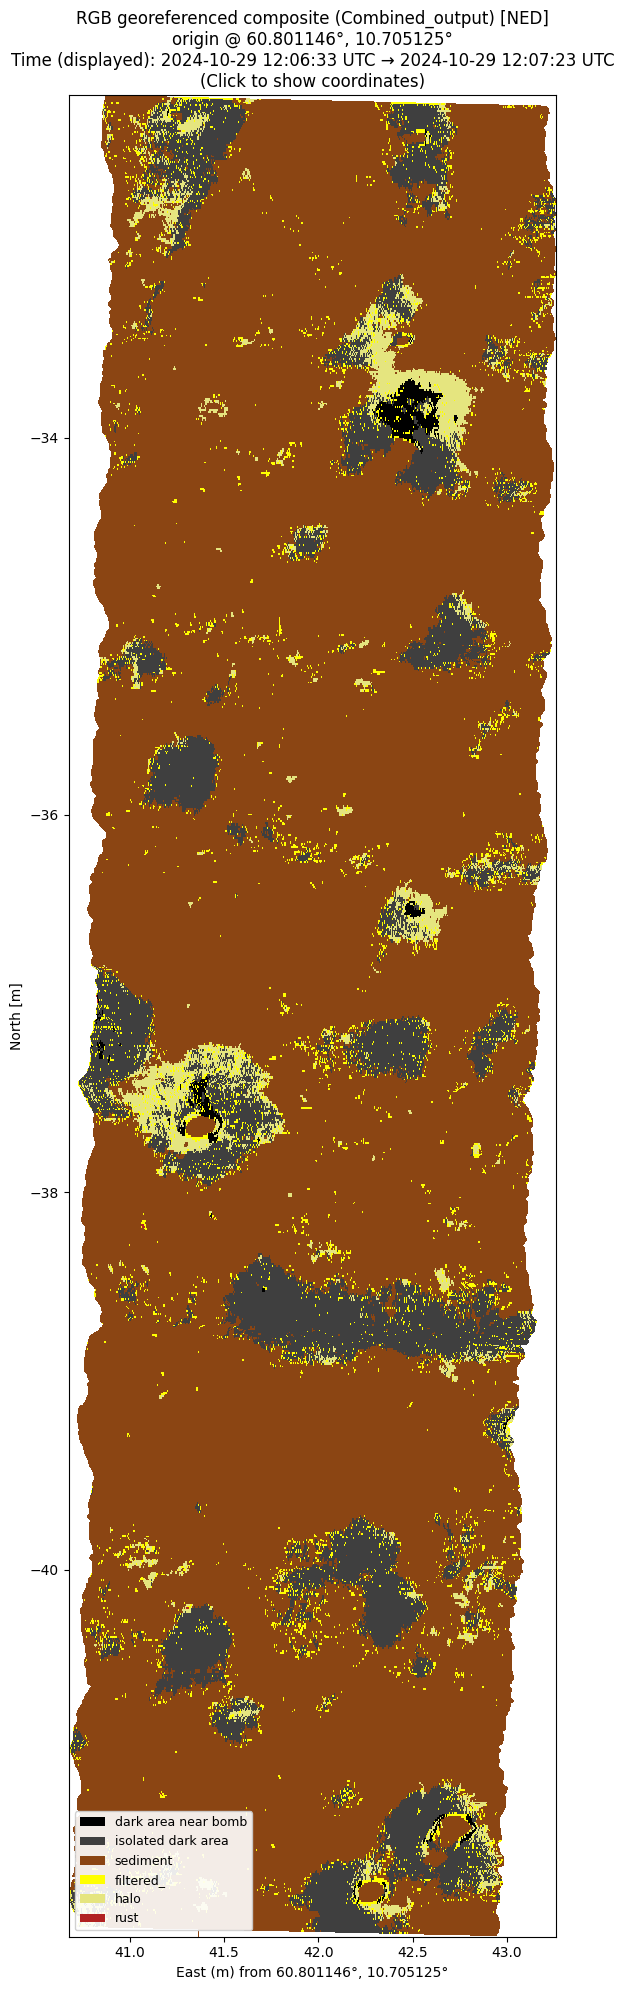

In [ ]:
# Convert filtered map to ROI format
print("📊 Plotting filtered classification map...")

# Map internal class names to display names requested by user
class_display_names = {
    "dark_bomb": "dark area near bomb",
    "dark_pit": "isolated dark area",
}

# Hardcoded color map for display names
roi_color_map = {
    "dark area near bomb": "#000000",  # COLOR_BOMBS
    "isolated dark area": "#3F3F3F",  # COLOR_DARK
    "sediment": "#8b4513",
    "rust": "#b12222",
    "halo": "#e5e57f",
}

filtered_rois = {}
# Use 'all_classes' which contains all unique classes in filtered map
for class_name in filtering_results["all_classes"]:
    mask = filtering_results["filtered_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + track_start) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        display_name = class_display_names.get(class_name, class_name)
        filtered_rois[display_name] = pixels

print(f"   Filtered ROIs: {list(filtered_rois.keys())}")
print(f"   Pixel counts:")
for class_name in sorted(filtered_rois.keys()):
    print(f"      {class_name}: {len(filtered_rois[class_name])} pixels")

# Plot filtered results, pass roi_color_map and overlay mode
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start,
    track_end=track_end,
    figsize=(50, 20),
    roi_collection=filtered_rois,
    roi_overlay_mode="solid",
    roi_color_map=roi_color_map,
    roi_solid_pixel_size=1,
    roi_legend_loc="lower left",
    roi_legend_markersize=50,
    roi_show_numbers=False,
    roi_legend_show_counts=False,  # Don't show pixel counts in legend labels
)

In [ ]:
# Merge filtered classes using neighborhood voting
print("\n🔀 STEP 8: MERGE FILTERED CLASSES (SMART REASSIGNMENT)")
print("=" * 60)

# Instead of merging all filtered_* to sediment, assign each filtered pixel
# to the MAJORITY class in its neighborhood (5x5 window)
# This is more context-aware and respects local class boundaries

merge_map = filtering_results["filtered_map"].copy()
unique_classes = np.unique(merge_map)

print(f"\n📊 Before merge:")
for class_name in sorted(unique_classes):
    count = np.sum(merge_map == class_name)
    print(f"   {class_name}: {count} pixels")

# Find all filtered pixels
filtered_classes = [c for c in unique_classes if "filtered_" in c]

if filtered_classes:
    print(f"\n🔍 Reassigning filtered pixels using 5x5 neighborhood voting...")

    # Window size (5x5 means radius=2)
    window_radius = 2

    # Track reassignments
    reassignment_summary = {}

    # Process each filtered pixel
    for filtered_class in filtered_classes:
        filtered_mask = merge_map == filtered_class
        filtered_pixels = np.argwhere(filtered_mask)

        print(f"   Processing {filtered_class}: {len(filtered_pixels)} pixels...")

        for row, col in filtered_pixels:
            # Get neighborhood bounds (with boundary checking)
            row_min = max(0, row - window_radius)
            row_max = min(merge_map.shape[0], row + window_radius + 1)
            col_min = max(0, col - window_radius)
            col_max = min(merge_map.shape[1], col + window_radius + 1)

            # Extract neighborhood
            neighborhood = merge_map[row_min:row_max, col_min:col_max]

            # Count votes for each class (exclude filtered classes from voting)
            vote_counts = {}
            for neighbor_class in np.unique(neighborhood):
                if "filtered_" not in neighbor_class:  # Only count non-filtered classes
                    count = np.sum(neighborhood == neighbor_class)
                    vote_counts[neighbor_class] = count

            # Assign to majority class (or sediment if no valid neighbors)
            if vote_counts:
                majority_class = max(vote_counts, key=vote_counts.get)
            else:
                majority_class = "sediment"  # Fallback

            # Reassign this pixel
            merge_map[row, col] = majority_class

            # Track reassignment
            reassignment_key = f"{filtered_class} → {majority_class}"
            reassignment_summary[reassignment_key] = (
                reassignment_summary.get(reassignment_key, 0) + 1
            )

    print(f"\n🔀 Reassignment summary:")
    for operation, count in sorted(reassignment_summary.items()):
        print(f"   {operation}: {count} pixels")
else:
    print(f"\n✅ No filtered classes to merge")
    reassignment_summary = {}

# Get final classes
final_classes = sorted(np.unique(merge_map))

print(f"\n📊 After merge:")
for class_name in final_classes:
    count = np.sum(merge_map == class_name)
    percentage = 100.0 * count / merge_map.size
    print(f"   {class_name}: {count} pixels ({percentage:.1f}%)")

# Store results
merge_results = {
    "validation_map": merge_map,
    "class_names": final_classes,
    "merge_summary": reassignment_summary,
}

print(f"\n✅ Smart merge complete!")
print(f"   Final classes: {merge_results['class_names']}")


🔀 STEP 8: MERGE FILTERED CLASSES (SMART REASSIGNMENT)

📊 Before merge:
   dark_bomb: 3956 pixels
   dark_pit: 111991 pixels
   filtered_: 28474 pixels
   halo: 29679 pixels
   rust: 53 pixels
   sediment: 784167 pixels

🔍 Reassigning filtered pixels using 5x5 neighborhood voting...
   Processing filtered_: 28474 pixels...
   rust: 53 pixels
   sediment: 784167 pixels

🔍 Reassigning filtered pixels using 5x5 neighborhood voting...
   Processing filtered_: 28474 pixels...

🔀 Reassignment summary:
   filtered_ → dark_bomb: 440 pixels
   filtered_ → dark_pit: 8121 pixels
   filtered_ → halo: 2910 pixels
   filtered_ → rust: 2 pixels
   filtered_ → sediment: 17001 pixels

📊 After merge:
   dark_bomb: 4396 pixels (0.5%)
   dark_pit: 120112 pixels (12.5%)
   halo: 32589 pixels (3.4%)
   rust: 55 pixels (0.0%)
   sediment: 801168 pixels (83.6%)

✅ Smart merge complete!
   Final classes: ['dark_bomb', 'dark_pit', 'halo', 'rust', 'sediment']

🔀 Reassignment summary:
   filtered_ → dark_bomb: 44

In [ ]:
# Create output directory for saving figures
output_dir_svm = Path.cwd().parent / "images_for_publication" / "057_SVM"
output_dir_svm.mkdir(parents=True, exist_ok=True)

print(f"📁 Output directory: {output_dir_svm}")
print(f"✅ Ready to save figures")

📊 Plotting final merged classification map...
   Merged ROIs: ['dark area near bomb', 'isolated dark area', 'halo', 'rust', 'sediment']
   Pixel counts:
      dark area near bomb: 4396 pixels
      halo: 32589 pixels
      isolated dark area: 120112 pixels
      rust: 55 pixels
      sediment: 801168 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
   Merged ROIs: ['dark area near bomb', 'isolated dark area', 'halo', 'rust', 'sediment']
   Pixel counts:
      dark area near bomb: 4396 pixels
      halo: 32589 pixels
      isolated dark area: 120112 pixels
      rust: 55 pixels
      sediment: 801168 pixels
🔧 DEBUG: plot_georef called with use_wavelength_colormap=False, wavelength_colormap_target=None
💡 Interactive mode: Click on the plot to display coordinates
💡 Interactive mode: Click on the plot to display coordinates


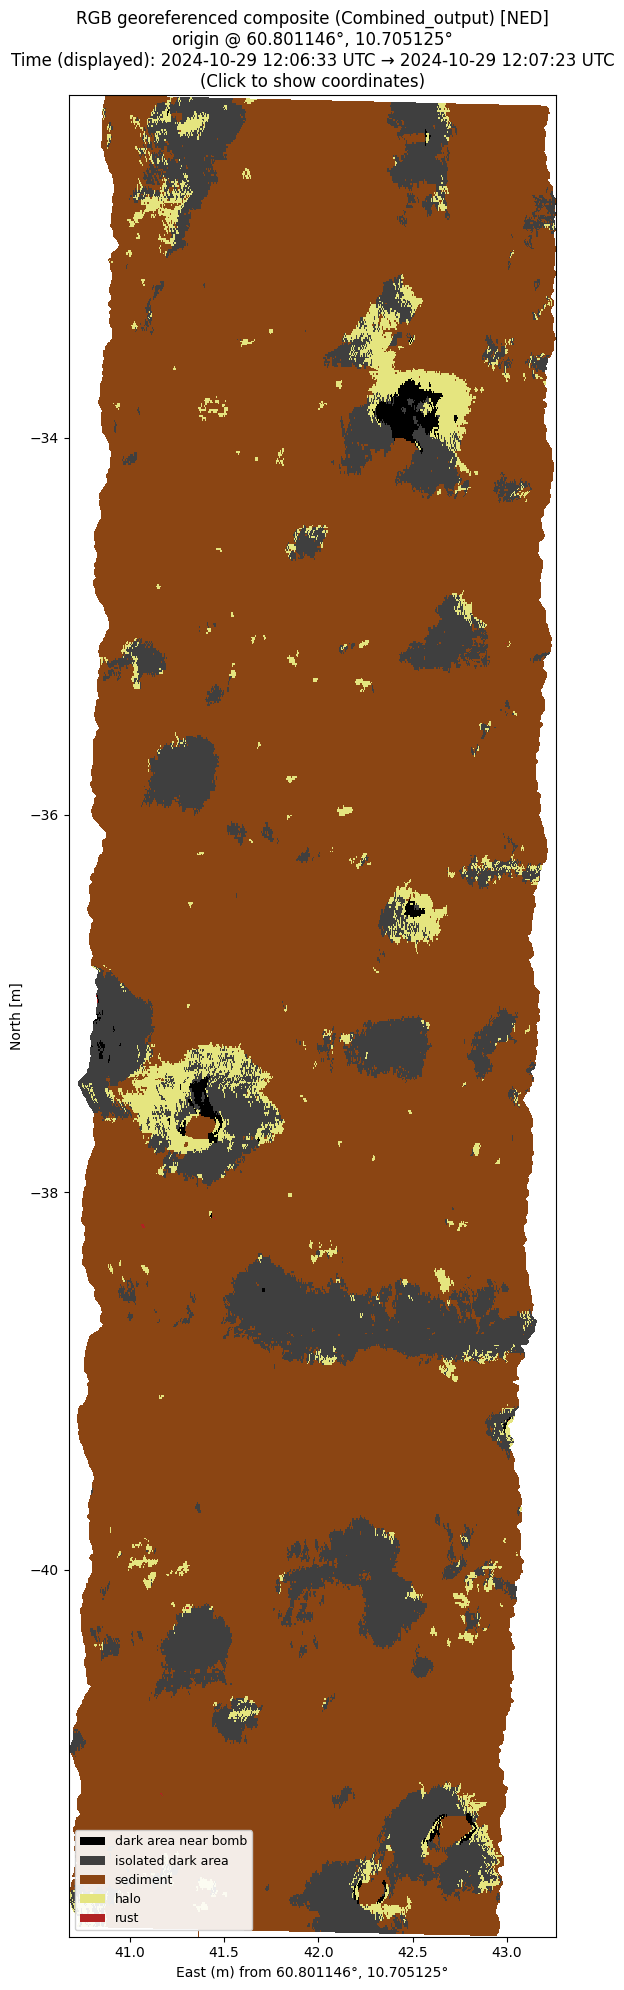

In [ ]:
# Plot final merged map (filtered classes merged back to sediment)
print("📊 Plotting final merged classification map...")

# Map class names to display names (same as before since we kept all original classes)
class_display_names = {
    "dark_bomb": "dark area near bomb",
    "dark_pit": "isolated dark area",
    # other classes keep their names
}

# Hardcoded color map (same as filtered plot)
roi_color_map = {
    "dark area near bomb": "#000000",  # Black
    "isolated dark area": "#3F3F3F",  # Dark gray
    "sediment": "#8b4513",  # Saddle brown
    "rust": "#b12222",  # Red
    "halo": "#e5e57f",  # Yellow
}

merged_rois = {}
# Build ROI collection from merged map
for class_name in merge_results["class_names"]:
    mask = merge_results["validation_map"] == class_name
    rows, cols = np.where(mask)
    pixels = [(col, row + track_start) for row, col in zip(rows, cols)]
    if len(pixels) > 0:
        display_name = class_display_names.get(class_name, class_name)
        merged_rois[display_name] = pixels

print(f"   Merged ROIs: {list(merged_rois.keys())}")
print(f"   Pixel counts:")
for class_name in sorted(merged_rois.keys()):
    print(f"      {class_name}: {len(merged_rois[class_name])} pixels")

# Plot merged results
cube.plot_georef(
    use_corrected=True,
    coordinate_system="NED",
    track_start=track_start,
    track_end=track_end,
    figsize=(50, 20),
    roi_collection=merged_rois,
    roi_overlay_mode="solid",
    roi_color_map=roi_color_map,
    roi_solid_pixel_size=1,
    roi_legend_loc="outside",
    roi_legend_markersize=50,
    roi_show_numbers=False,
    roi_legend_show_counts=False,
    display_only_mosaic=True,  # NEW: Set to True to remove axes/labels/ticks/borders
    roi_legend_frameon=False,  # NEW: No legend border
    save_file=str(
        output_dir_svm / "057_mosaic_SVM5_with_legend.pdf"
    ),  # NEW: Save as PDF
    save_dpi=300,
)

## Summary

**What we did:**
1. ✅ Loaded SVM model trained on 028 transect (dev30)
2. ✅ Applied same preprocessing to 057 transect
3. ✅ Classified 057 using 028's model (cross-transect transfer!)
4. ✅ Applied filtering to remove small clusters
5. ✅ Visualized results with plot_georef

**Key insight**: Testing if the 028-trained model generalizes to 057!

---

## 📊 COMPREHENSIVE CLASSIFICATION ANALYSIS

Generate detailed metrics, visualizations, and statistics for cross-transect transfer (028 model → 057 data).

📊 CROSS-TRANSECT TRANSFER ANALYSIS: 028 MODEL → 057 DATA
Model: SVM trained on transect 028 (5-class)
Application: Applied to transect 057
Purpose: Test model generalization across different seafloor sites

CLASSIFICATION ANALYSIS SUMMARY
Total pixels in map: 958,320
Unknown / unclassified (before): 0 pixels (0.00%)
Unknown / unclassified (after): 0 pixels (0.00%)

Per-class counts (before filtering):
  sediment: 784,167 pixels (81.83%)
  rust: 53 pixels (0.01%)
  dark_bomb: 5,383 pixels (0.56%)
  dark_pit: 125,100 pixels (13.05%)
  halo: 43,617 pixels (4.55%)

Per-class counts (after filtering):
  sediment: 784,167 pixels (81.83%)
  rust: 53 pixels (0.01%)
  dark_bomb: 3,956 pixels (0.41%)
  dark_pit: 111,991 pixels (11.69%)
  halo: 29,679 pixels (3.10%)

Filtering impact (removed pixels):
  dark_bomb: removed 1,427 px (26.51%)
  dark_pit: removed 13,109 px (10.48%)
  halo: removed 13,938 px (31.96%)

Cluster statistics (connected components):
  sediment: 1685 clusters, largest=768791

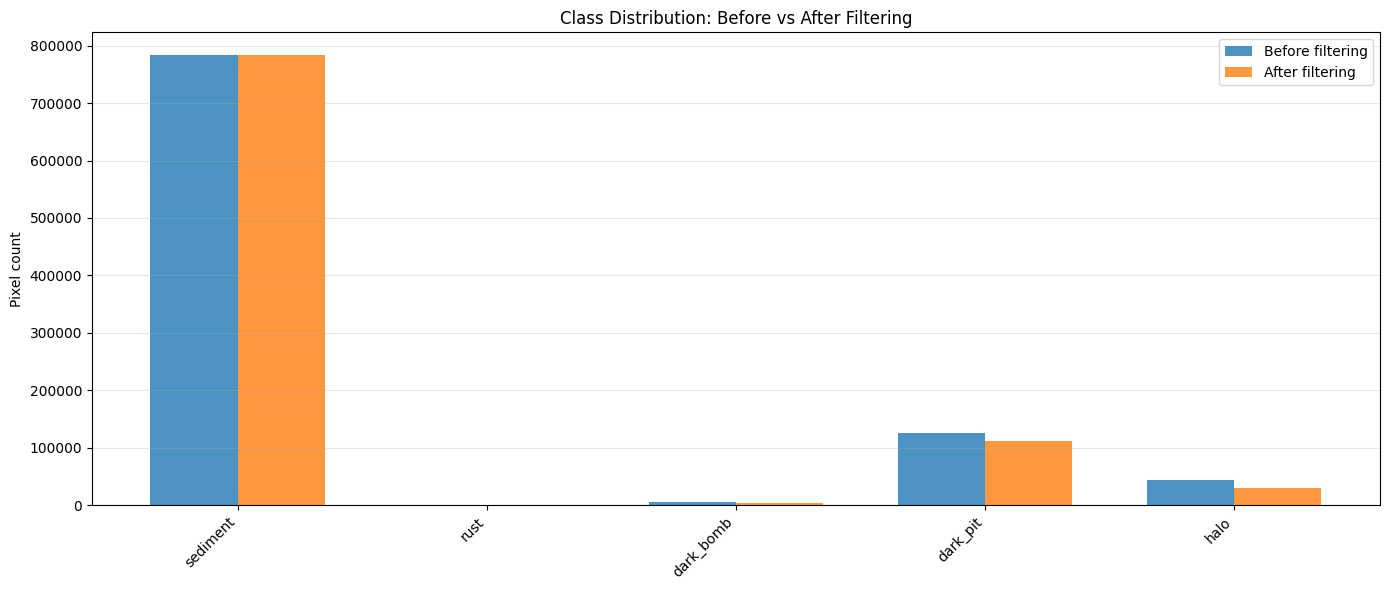

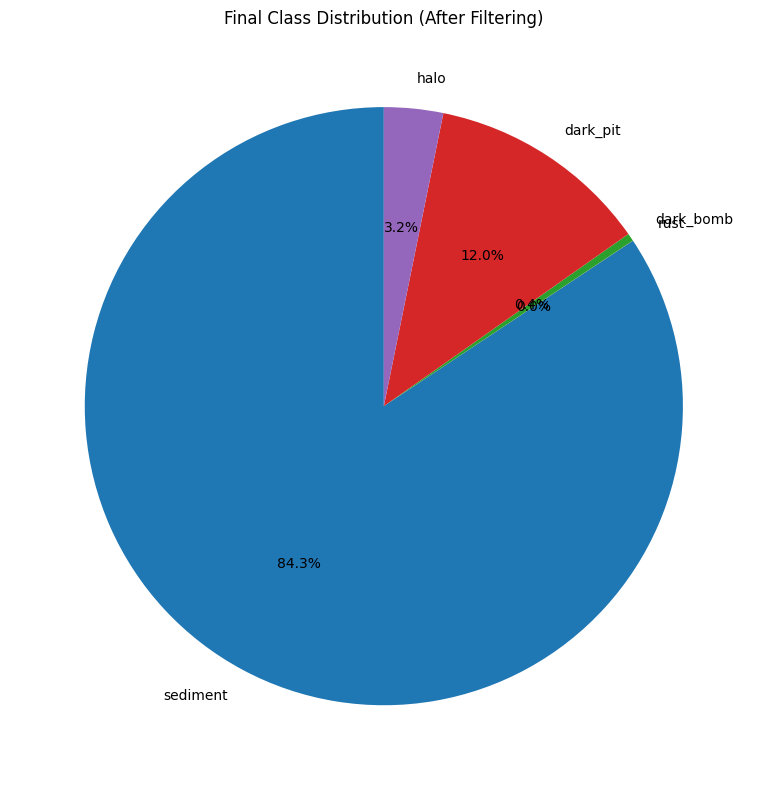

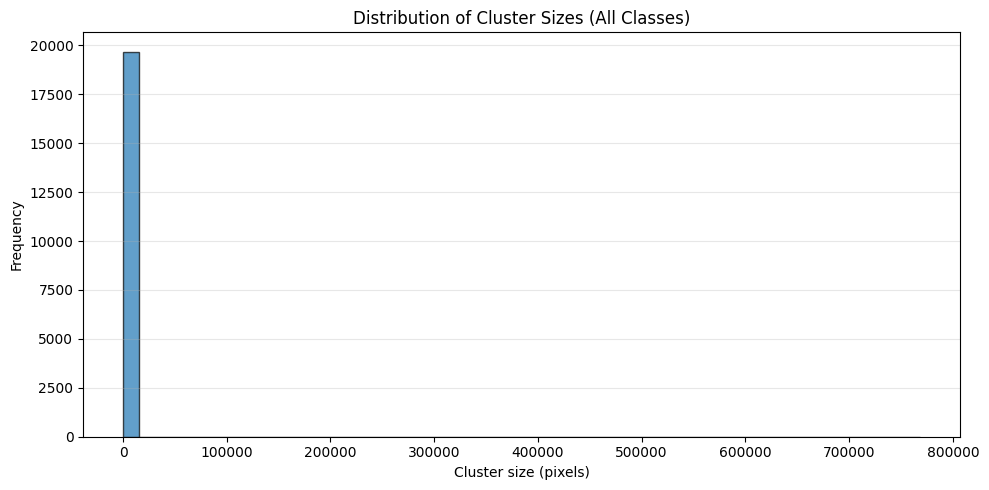


✅ Analysis complete. Returned metrics dictionary.

📝 CROSS-TRANSFER NARRATIVE SUMMARY
The 028 model (trained on 5 classes) was applied to 057 transect.
Total pixels classified: 958,320

Class distribution in 057 when using 028 model:
  • sediment:
      Before filtering: 784,167 pixels
      After filtering: 784,167 pixels (81.83%)
  • rust:
      Before filtering: 53 pixels
      After filtering: 53 pixels (0.01%)
  • dark_bomb:
      Before filtering: 5,383 pixels
      After filtering: 3,956 pixels (0.41%)
      Removed: 1,427 pixels (small clusters)
  • dark_pit:
      Before filtering: 125,100 pixels
      After filtering: 111,991 pixels (11.69%)
      Removed: 13,109 pixels (small clusters)
  • halo:
      Before filtering: 43,617 pixels
      After filtering: 29,679 pixels (3.10%)
      Removed: 13,938 pixels (small clusters)

🔍 KEY INSIGHT:
   Compare these results with notebook 6 (057 model on 057 data)
   to assess how well the 028 model generalizes to a different site.


In [ ]:
# Import the comprehensive analysis function
from utils.uhi.classification_analysis import analyze_classification_results

print("=" * 80)
print("📊 CROSS-TRANSECT TRANSFER ANALYSIS: 028 MODEL → 057 DATA")
print("=" * 80)
print(f"Model: SVM trained on transect 028 (5-class)")
print(f"Application: Applied to transect 057")
print(f"Purpose: Test model generalization across different seafloor sites")
print("=" * 80)

# Gather classification and filtering results
cls_map = (
    classification_results.get("classification_map")
    if "classification_results" in globals()
    else None
)
filt_map = (
    filtering_results.get("filtered_map") if "filtering_results" in globals() else None
)
class_names_var = (
    classification_results.get("class_names")
    if "classification_results" in globals()
    else None
)

if cls_map is None:
    print("❌ ERROR: classification_results not found!")
    print("   Please run the classification cells first.")
else:
    # Run comprehensive analysis
    metrics_028_to_057 = analyze_classification_results(
        classification_map=cls_map,
        filtered_map=filt_map,
        class_names=class_names_var,
        track_start=track_start if "track_start" in globals() else 0,
        figsize=(14, 6),
        show_plots=True,
        save_csv="./saved_data/classification_summary_028_to_057.csv",
    )

    print("\n" + "=" * 80)
    print("📝 CROSS-TRANSFER NARRATIVE SUMMARY")
    print("=" * 80)
    print(f"The 028 model (trained on 5 classes) was applied to 057 transect.")
    print(f"Total pixels classified: {metrics_028_to_057['total_pixels']:,}")
    print(f"\nClass distribution in 057 when using 028 model:")

    if metrics_028_to_057["counts_after"] is not None:
        for cn in class_names_var:
            before = metrics_028_to_057["counts_before"].get(cn, 0)
            after = metrics_028_to_057["counts_after"].get(cn, 0)
            pct_after = 100.0 * after / metrics_028_to_057["total_pixels"]
            removed = before - after
            print(f"  • {cn}:")
            print(f"      Before filtering: {before:,} pixels")
            print(f"      After filtering: {after:,} pixels ({pct_after:.2f}%)")
            if removed > 0:
                print(f"      Removed: {removed:,} pixels (small clusters)")
    else:
        for cn in class_names_var:
            count = metrics_028_to_057["counts_before"].get(cn, 0)
            pct = 100.0 * count / metrics_028_to_057["total_pixels"]
            print(f"  • {cn}: {count:,} pixels ({pct:.2f}%)")

    print("\n🔍 KEY INSIGHT:")
    print("   Compare these results with notebook 6 (057 model on 057 data)")
    print("   to assess how well the 028 model generalizes to a different site.")
    print("=" * 80)

---

## 💾 EXPORT COVERAGE STATISTICS

Save classification coverage percentages to CSV for cross-notebook comparison.


In [ ]:
# Export coverage statistics for notebook 10 (028 model on 057 transect)
import pandas as pd
import os

# Create coverage_stats directory if it doesn't exist
os.makedirs("./coverage_stats", exist_ok=True)

if "classification_results" in globals() and classification_results:
    # Calculate coverage percentages from classification results
    total_pixels = classification_results["classification_map"].size

    coverage_data = []
    for class_name in classification_results["class_names"]:
        count = np.sum(classification_results["classification_map"] == class_name)
        percentage = 100.0 * count / total_pixels
        coverage_data.append(
            {
                "notebook": "10_apply_028_model_to_057",
                "model": "028_on_057",
                "region": "full_transect",
                "class": class_name,
                "pixels": count,
                "percentage": percentage,
            }
        )

    # Save to CSV
    df_coverage = pd.DataFrame(coverage_data)
    output_file = "./coverage_stats/028_on_057_coverage.csv"
    df_coverage.to_csv(output_file, index=False)

    print("✅ Coverage statistics exported!")
    print(f"   File: {output_file}")
    print(f"\n📊 Coverage Summary:")
    print(df_coverage[["region", "class", "percentage"]].to_string(index=False))
else:
    print("❌ ERROR: classification_results not found!")
    print("   Run the classification cells first.")

✅ Coverage statistics exported!
   File: ./coverage_stats/028_on_057_coverage.csv

📊 Coverage Summary:
       region     class  percentage
full_transect  sediment   81.827260
full_transect      rust    0.005531
full_transect dark_bomb    0.561712
full_transect  dark_pit   13.054095
full_transect      halo    4.551402
